# Step 1: Precompute Basin Resource Matrix

## CO₂BLOCK capacity assessment for all basins × storage periods

This notebook runs the slow CO₂BLOCK physics calculation once and saves the
result as a reusable resource library.

### What this step does

For each basin in `Global.xlsx` and each storage period (10, 20, ..., 150 years):
- Read basin geology (depth, permeability, porosity, area, fluid properties)
- Evaluate equation of state (CO₂ density, viscosity via Redlich-Kwong / Altunin)
- Compute geomechanical pressure limits (Mohr-Coulomb shear + tensile failure)
- Search across well-count × well-spacing configurations (using Iman's MATLAB reference setup)
- Use the same initial total-rate guess as MATLAB: `M0 = perm / 1e-13`
- Apply constraints: `maxQ` per well, plume interaction, min spacing feasibility
- Keep the optimal configuration (max capacity above `minQ` threshold)

### Output

An m × n resource matrix saved to disk:
- `m` = number of basins
- `n` = number of storage periods (15 columns: 10 yr, 20 yr, ..., 150 yr)
- Each cell = maximum feasible injection rate for that basin at that duration

This matrix is independent of growth scenarios; it depends only on geology
and screening parameters. Run this notebook once, then reuse the output in Step 2.

### Parameters (aligned with Iman's MATLAB reference)

| Parameter | Value | Description |
|-----------|------:|-------------|
| `nr_dist` | 100 | Well-spacing scenarios |
| `maxQ` | 20 Mt/yr | Max injection rate per well |
| `minQ` | 1 Mt/yr | Min meaningful site rate |
| `dist_min` | 2 km | Minimum inter-well distance |
| `inj_duration` | 150 yr | Maximum injection / storage period |
| `storage_period_step` | 10 yr | Storage period increment (MATLAB default) |

### Running options

| Method | Command | Speed | Use when |
|--------|---------|-------|----------|
| Notebook | Run cells sequentially in Jupyter | Serial (~15 min) | Interactive exploration, figure tuning |
| Script | `python run_step1_precompute.py --workers 4` | Parallel (~3-5 min) | Production runs, CI/CD |

The standalone script `code/run_step1_precompute.py` is the `.py` equivalent of this
notebook. It uses `ProcessPoolExecutor` with multiple workers to parallelise the
CO₂BLOCK physics across (basin, period) pairs, which is not possible inside a
Jupyter cell because Python's multiprocessing cannot pickle functions defined in
notebook cells. The script produces identical output files; once complete,
set `SKIP_PRECOMPUTE = True` in this notebook and run the figure cells directly.

### Scripts in `code/`

| File | Purpose |
|------|---------|
| `run_step1_precompute.py` | Parallel `.py` version of this notebook (Step 1) |
| `run_step2_screening.py` | Parallel `.py` version of `step2_allocation_screening.ipynb` (Step 2) |
| `co2block_py/` | Shared library: CO₂BLOCK physics, allocation algorithm, screening logic |

In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Project paths
NB_DIR = Path.cwd()
SCREENING_ROOT = NB_DIR.parent
CODE_ROOT = SCREENING_ROOT / 'code'

if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from co2block_py.core import CalculationConfig, build_regional_summary, calculate_site
from co2block_py.screening import assign_screening_case

# Input / output
BASIN_FILE = SCREENING_ROOT / 'input' / 'basin_data' / 'Global.xlsx'
OUTPUT_ROOT = SCREENING_ROOT / 'output' / 'step1_precompute'
PRECOMPUTE_DIR = OUTPUT_ROOT / 'precompute'
PRECOMPUTE_DIR.mkdir(parents=True, exist_ok=True)

# CO₂BLOCK parameters (Iman reference)
INJ_DURATION_YR        = 150   # periods = [10, 20, ..., 150]
STORAGE_PERIOD_STEP_YR = 10   # MATLAB default step size
NR_DIST                = 100
MAX_Q_MT_YR            = 20.0
MIN_Q_MT_YR            = 1.0
SCREENING_SCOPE        = 'country'   # 'country' or 'region'

print(f'Basin database: {BASIN_FILE}')
print(f'Output dir:     {PRECOMPUTE_DIR}')
print(f'Parameters:     nr_dist={NR_DIST}, maxQ={MAX_Q_MT_YR}, minQ={MIN_Q_MT_YR}')
print(f'Periods:        {list(range(STORAGE_PERIOD_STEP_YR, INJ_DURATION_YR + 1, STORAGE_PERIOD_STEP_YR))}')

Basin database: /Users/xg320/Desktop/IC-Sam-works/paper/Iman-2026/02_co2block_screening/input/basin_data/Global.xlsx
Output dir:     /Users/xg320/Desktop/IC-Sam-works/paper/Iman-2026/02_co2block_screening/output/step1_precompute/precompute
Parameters:     nr_dist=100, maxQ=20.0, minQ=1.0
Periods:        [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


## Load basin database and assign screening cases

Read `Global.xlsx` and tag each basin with its screening case (country or region).


In [2]:
basin_df = pd.read_excel(BASIN_FILE).copy()
basin_df.insert(0, 'region_no', range(1, len(basin_df) + 1))
basin_df['AssignedCountry'] = basin_df['Majority Country']
basin_df['RegionGroup'] = basin_df['Region']
basin_df['screening_case'] = basin_df.apply(
    lambda row: assign_screening_case(
        row.get('Majority Country'), row.get('Region'), scope=SCREENING_SCOPE),
    axis=1,
)

# V8 active study pool (10 regions). EU is Europe without UK.
SCREENING_COUNTRIES = ['US', 'China', 'Indonesia', 'Australia', 'UK', 'Canada', 'Thailand', 'EU', 'Middle East', 'Brazil']
assigned = basin_df[basin_df['screening_case'].isin(SCREENING_COUNTRIES)].copy()

print(f'Total basins in Global.xlsx: {len(basin_df)}')
print(f'Basins for screening:        {len(assigned)}')
print()
for country in SCREENING_COUNTRIES:
    n = len(assigned[assigned['screening_case'] == country])
    print(f'  {country:20s} {n:3d} basins')


Total basins in Global.xlsx: 203
Basins for screening:        123

  US                    20 basins
  China                 21 basins
  Indonesia             11 basins
  Australia              9 basins
  UK                     6 basins
  Canada                 3 basins
  Thailand               2 basins
  EU                    28 basins
  Middle East           13 basins
  Brazil                10 basins


## Precompute resource matrix

Run CO₂BLOCK for every (basin, storage period) pair. This is the slow step.

The result is saved to `precompute/basin_period_resource_long.csv`.
Subsequent runs can skip this cell by setting `SKIP_PRECOMPUTE = True`.


In [3]:
SKIP_PRECOMPUTE = True  # Set True after first successful run

long_csv = PRECOMPUTE_DIR / 'basin_period_resource_long.csv'
metadata_csv = PRECOMPUTE_DIR / 'basin_metadata.csv'

if SKIP_PRECOMPUTE and long_csv.exists():
    print('Loading precomputed resource matrix from cache...')
    resource_long = pd.read_csv(long_csv)
    print(f'Loaded {len(resource_long):,} rows')
else:
    from tqdm.auto import tqdm

    basins_to_compute = assigned[['region_no']].drop_duplicates()
    periods = list(range(STORAGE_PERIOD_STEP_YR, INJ_DURATION_YR + 1, STORAGE_PERIOD_STEP_YR))

    tasks = [
        (int(r['region_no']), period)
        for _, r in basins_to_compute.iterrows()
        for period in periods
    ]

    total_tasks = len(tasks)
    print(f'Computing basin-period resource matrix...')
    print(f'  Basins:      {len(basins_to_compute)}')
    print(f'  Periods:     {periods}')
    print(f'  Total tasks: {total_tasks}')

    def evaluate_task(args):
        region_no, period = args
        calc = CalculationConfig(
            data_path=BASIN_FILE,
            site_no=region_no,
            correction='off',
            dist_min_km=2.0,
            dist_max_km='auto',
            nr_dist=NR_DIST,
            nr_well_max='auto',
            rw_m=0.2,
            time_yr=period,
            max_q_mt_per_year=MAX_Q_MT_YR,
            min_q_mt_per_year=MIN_Q_MT_YR,
        )
        result = calculate_site(calc)
        summary, _, _ = build_regional_summary(result, MIN_Q_MT_YR)

        def safe_float(v):
            f = float(v)
            return f if math.isfinite(f) else 0.0

        return {
            'Region_no': region_no,
            'Region_name': summary.region,
            'Period_yr': period,
            'Region_Q_Mt_yr': safe_float(summary.region_q_mt_per_year),
            'Number_of_Wells': int(summary.number_of_wells),
            'Max_Capacity_Gt': safe_float(summary.max_capacity_gt),
            'Max_Q_Mt_yr': safe_float(summary.max_q_mt_per_year),
            'Optimum_Q_Mt_yr': safe_float(summary.optimum_q_mt_per_year),
            'Distance_km': safe_float(summary.distance_km),
        }

    # Main loop with tqdm progress bar
    rows = []
    basin_names = basin_df.set_index('region_no')['Basin Name'].to_dict()

    pbar = tqdm(tasks, total=total_tasks,
                desc='CO₂BLOCK precompute',
                bar_format='{l_bar}{bar:30}{r_bar}',
                unit='task')

    basins_seen = set()
    for task in pbar:
        region_no, period = task
        rows.append(evaluate_task(task))
        basins_seen.add(region_no)
        name = basin_names.get(region_no, f'basin_{region_no}')
        pbar.set_postfix_str(
            f'basins: {len(basins_seen)}/{len(basins_to_compute)} | '
            f'{name} @ {period}yr',
            refresh=True,
        )

    pbar.close()

    resource_long = pd.DataFrame(rows).sort_values(
        ['Region_no', 'Period_yr']).reset_index(drop=True)

    # Add country/region metadata
    meta_map = basin_df.set_index('region_no')[
        ['AssignedCountry', 'RegionGroup']].to_dict('index')
    resource_long['AssignedCountry'] = resource_long['Region_no'].map(
        lambda x: meta_map.get(x, {}).get('AssignedCountry', 'Unknown'))
    resource_long['RegionGroup'] = resource_long['Region_no'].map(
        lambda x: meta_map.get(x, {}).get('RegionGroup', 'Unknown'))

    resource_long.to_csv(long_csv, index=False)
    print(f'\nPrecompute complete: {len(resource_long):,} rows saved to {long_csv}')

# Study-region grouping (v8): map each basin's raw majority country / region
# to its screening case (US, China, ..., EU, Middle East, Brazil). Used for
# figures and as a convenience column; step 2 still resolves from
# AssignedCountry/RegionGroup via resolve_region_nos.
if 'ScreeningCase' not in resource_long.columns:
    resource_long['ScreeningCase'] = resource_long.apply(
        lambda r: assign_screening_case(r['AssignedCountry'], r['RegionGroup']), axis=1)
    resource_long.to_csv(long_csv, index=False)

# Save metadata
metadata_df = resource_long[['Region_no', 'Region_name', 'AssignedCountry', 'RegionGroup', 'ScreeningCase']
    ].drop_duplicates().sort_values('Region_no')
metadata_df.to_csv(metadata_csv, index=False)

print(f'\nResource matrix: {resource_long.shape[0]:,} rows  '
      f'({resource_long["Region_no"].nunique()} basins × '
      f'{resource_long["Period_yr"].nunique()} periods)')
print(f'Metadata: {len(metadata_df)} basins')


Loading precomputed resource matrix from cache...
Loaded 1,845 rows

Resource matrix: 1,845 rows  (123 basins × 15 periods)
Metadata: 123 basins


## Preview resource matrix


In [4]:
# Basins per country
print('Basins per screening case:')
print(metadata_df.groupby('ScreeningCase')['Region_no'].count()
      .rename('n_basins').to_frame().to_string())

# Rate matrix pivot (preview)
print('\nRate matrix pivot (Region_Q_Mt_yr, first 5 basins):')
rate_pivot = resource_long.pivot_table(
    index=['Region_no', 'Region_name'],
    columns='Period_yr',
    values='Region_Q_Mt_yr',
    aggfunc='first',
)
print(rate_pivot.head().round(1).to_string())

# Country-level totals at 150 yr period
t150 = resource_long[resource_long['Period_yr'] == INJ_DURATION_YR]
country_totals = t150.groupby('ScreeningCase').agg(
    n_basins=('Region_no', 'nunique'),
    total_rate_Mt_yr=('Region_Q_Mt_yr', 'sum'),
    total_wells=('Number_of_Wells', 'sum'),
).round(1)
print(f'\nCountry-level totals at {INJ_DURATION_YR}-year storage period:')
print(country_totals.to_string())


Basins per screening case:
               n_basins
ScreeningCase          
Australia             9
Brazil               10
Canada                3
China                21
EU                   28
Indonesia            11
Middle East          13
Thailand              2
UK                    6
US                   20

Rate matrix pivot (Region_Q_Mt_yr, first 5 basins):
Period_yr                              10      20      30      40      50      60      70      80      90      100     110     120     130     140    150
Region_no Region_name                                                                                                                                    
1         Adavale                      0.2     0.2     0.2     0.2     0.2     0.2     0.2     0.2     0.2     0.2     0.2     0.2     0.2     0.2    0.2
3         Al Daww                   2099.2  1096.3   724.0   540.3   426.8   363.1   298.5   266.9   241.2   211.8   195.2   169.1   156.6   146.6  138.4
6         Anadar

## Figure 1: Basin resource landscape (150-year assessment)

Four-panel summary of the precomputed CO₂BLOCK resource matrix:

| Panel | Content |
|-------|---------|
| (a) | Basin × period heatmap: full resource matrix at a glance, grouped by country |
| (b) | Pareto chart: resource concentration, how many basins dominate total capacity |
| (c) | Country-level totals: annual rate bar plus basin count and cumulative Gt |
| (d) | Basin-level strip plot: within-country heterogeneity, dot size = well count |

Saved: /Users/xg320/Desktop/IC-Sam-works/paper/Iman-2026/02_co2block_screening/output/step1_precompute/figures/fig1_resource_landscape.pdf


Saved: /Users/xg320/Desktop/IC-Sam-works/paper/Iman-2026/02_co2block_screening/output/step1_precompute/figures/fig1_resource_landscape.png


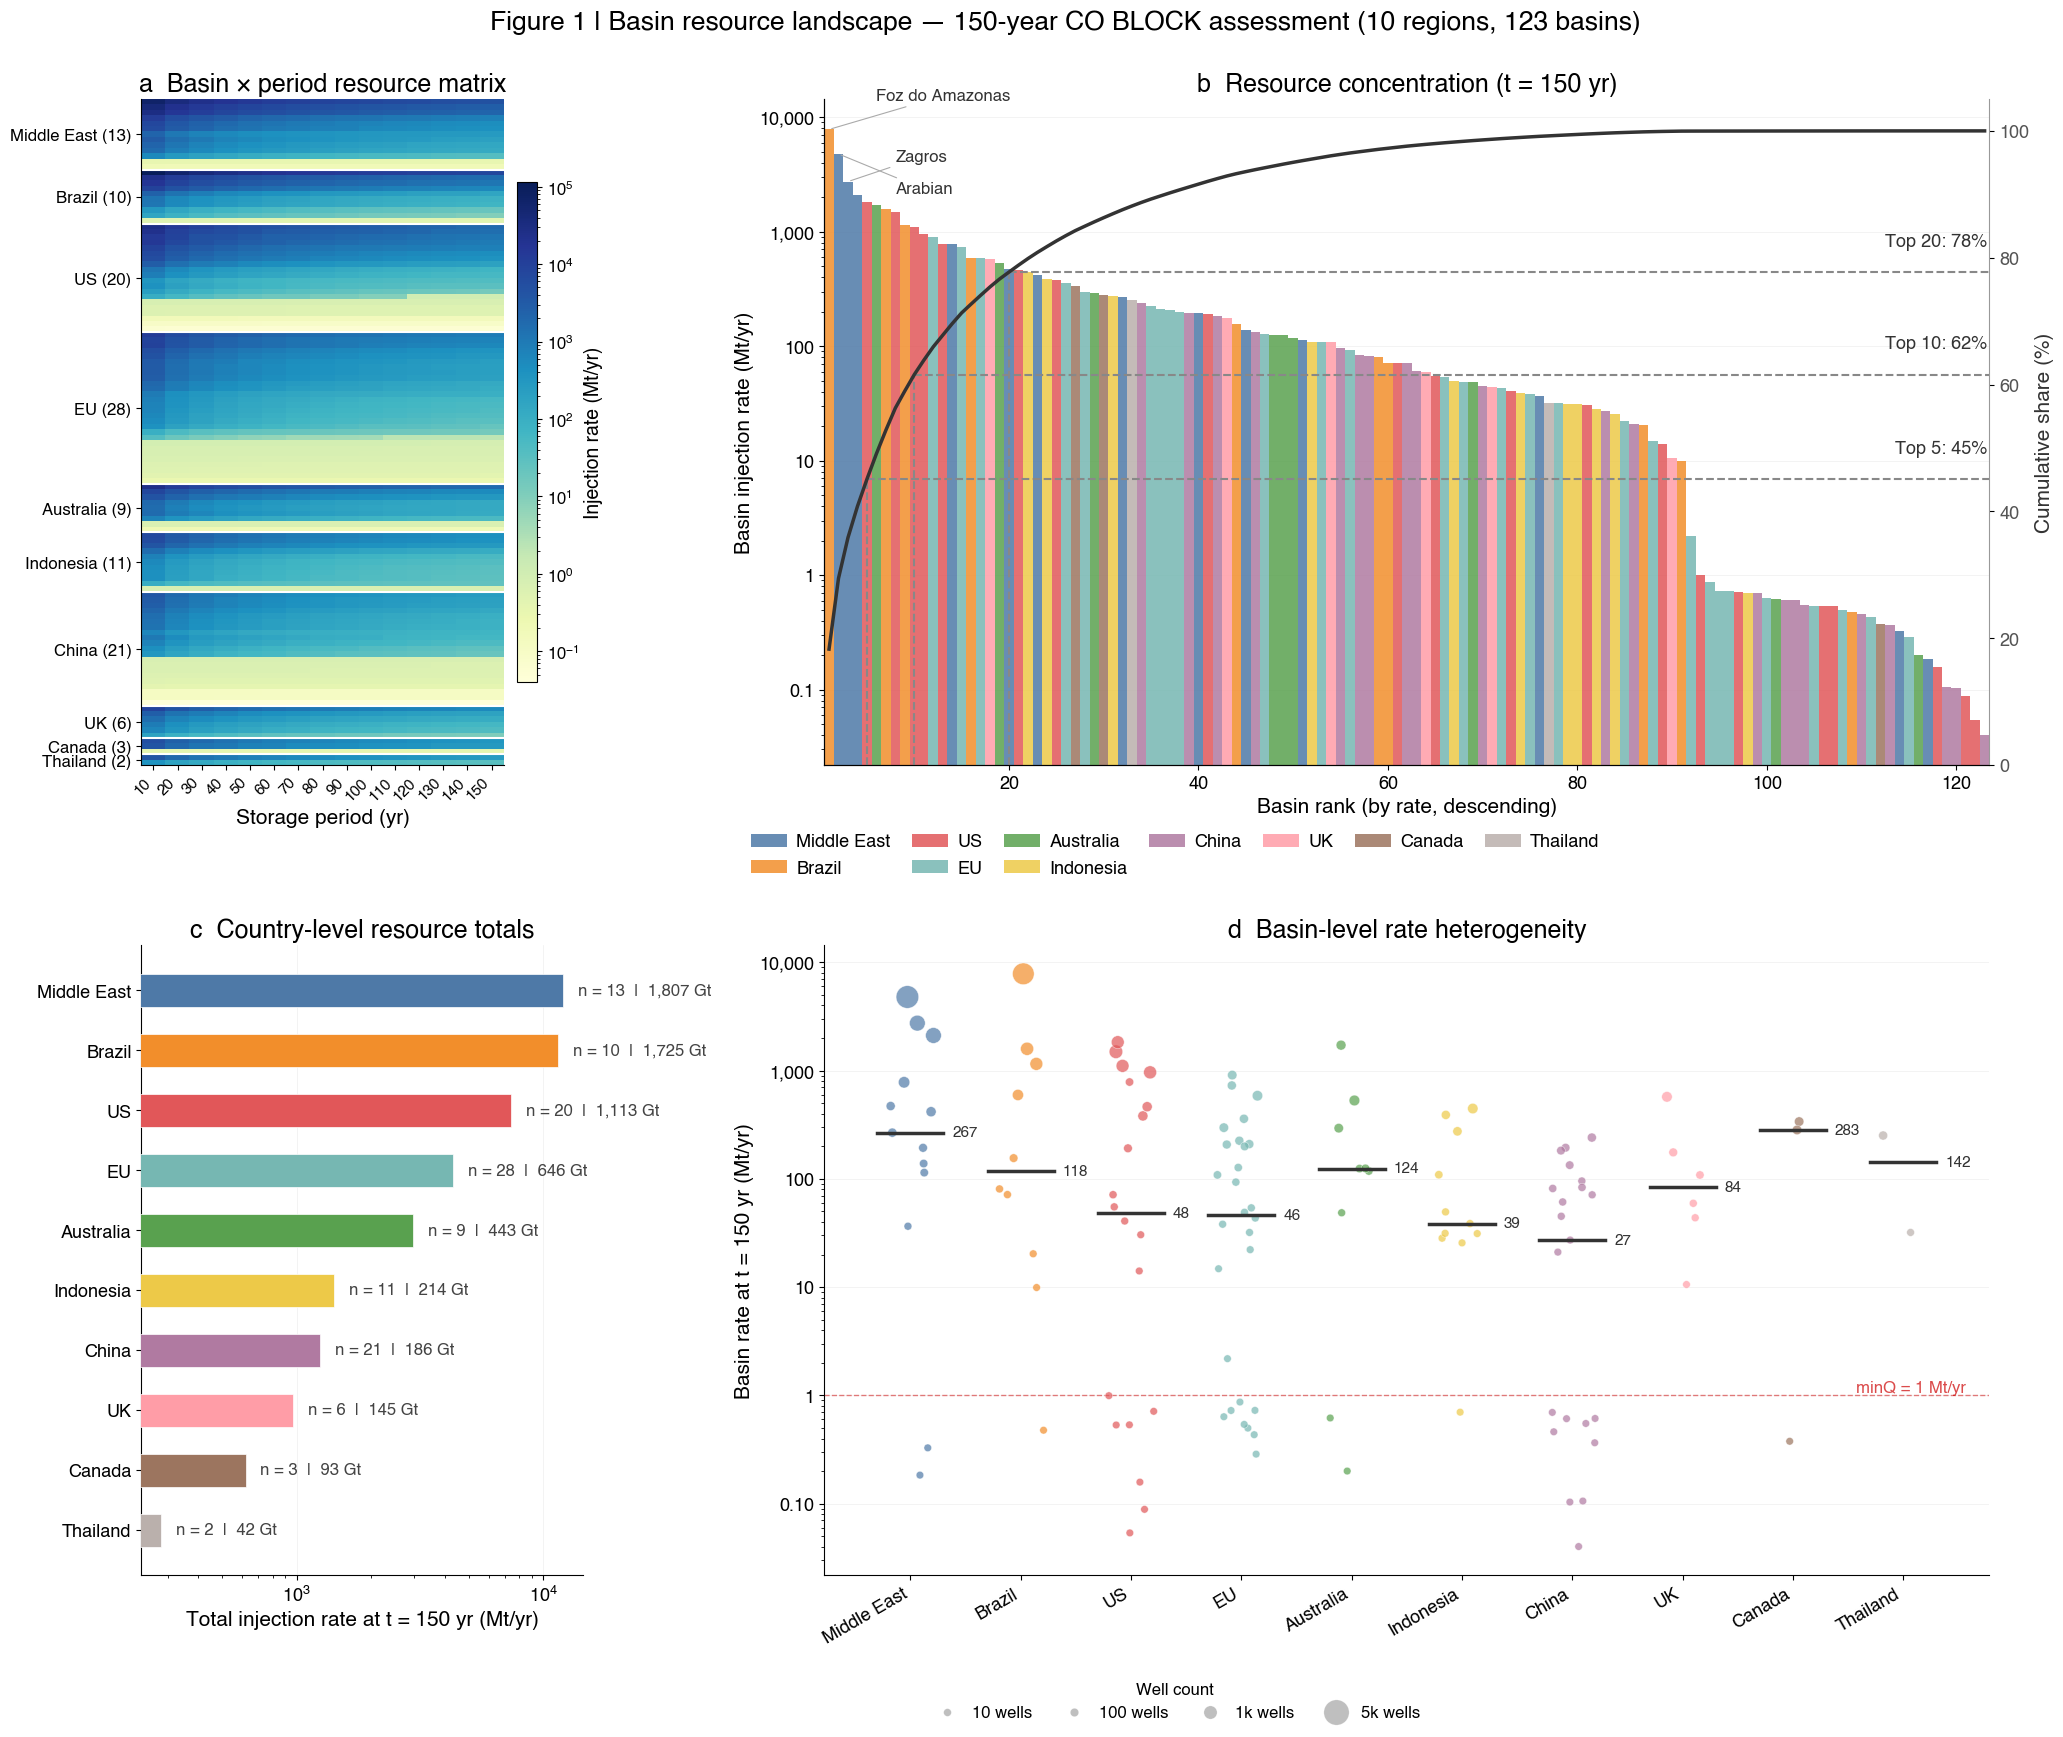

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Global style (Nature Portfolio , enlarged for readability)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 16,
    'axes.titlesize': 18, 'axes.titleweight': 'bold',
    'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
})

FIGURES_DIR = OUTPUT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Data prep
resource = resource_long.copy()
# v8: colour/group panels by study region (EU, Middle East, Brazil aggregated),
# not raw majority country. AssignedCountry in the saved matrix is unchanged.
resource['AssignedCountry'] = resource['ScreeningCase']
PERIODS = sorted(resource['Period_yr'].unique())
t_short, t_long = min(PERIODS), max(PERIODS)

country_totals_sort = (
    resource[resource['Period_yr'] == t_long]
    .groupby('AssignedCountry')['Region_Q_Mt_yr'].sum()
    .sort_values(ascending=False)
)
COUNTRIES = country_totals_sort.index.tolist()

_CPAL = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f',
         '#edc948', '#b07aa1', '#ff9da7', '#9c755f', '#bab0ac']
COUNTRY_COLORS = {c: _CPAL[i % len(_CPAL)] for i, c in enumerate(COUNTRIES)}

# (a) Heatmap data
pivot_rate = resource.pivot(index='Region_no', columns='Period_yr', values='Region_Q_Mt_yr')
meta = resource[['Region_no', 'Region_name', 'AssignedCountry']].drop_duplicates().set_index('Region_no')
pivot_rate = pivot_rate.join(meta)
pivot_rate['country_rank'] = pivot_rate['AssignedCountry'].map(
    {c: i for i, c in enumerate(COUNTRIES)})
pivot_rate = pivot_rate.sort_values(
    ['country_rank', t_long], ascending=[True, False]).reset_index()

heatmap_data = pivot_rate[PERIODS].values
basin_countries = pivot_rate['AssignedCountry'].values

country_boundaries = []
prev = None
for i, c in enumerate(basin_countries):
    if c != prev:
        country_boundaries.append((i, c))
        prev = c

# (b) Pareto data
t_ref = t_long
t_ref_df = resource[resource['Period_yr'] == t_ref].copy()
t_ref_sorted = t_ref_df.sort_values('Region_Q_Mt_yr', ascending=False).reset_index(drop=True)
t_ref_sorted['rank'] = range(1, len(t_ref_sorted) + 1)
total_rate = t_ref_sorted['Region_Q_Mt_yr'].sum()
t_ref_sorted['cum_pct'] = t_ref_sorted['Region_Q_Mt_yr'].cumsum() / total_rate * 100

# (c) Country totals
ct = (
    resource[resource['Period_yr'] == t_ref]
    .groupby('AssignedCountry')
    .agg(total_rate=('Region_Q_Mt_yr', 'sum'), n_basins=('Region_no', 'nunique'))
    .reindex(COUNTRIES)
)
ct['cumulative_gt'] = ct['total_rate'] * t_ref / 1000

# (d) Strip data
strip_df = resource[resource['Period_yr'] == t_ref].copy()
def well_to_size(w):
    return 30 + (w / 5000) * 300

# Figure 1: 4 panels, enlarged for readability
fig = plt.figure(figsize=(22, 18))

gs_top = gridspec.GridSpec(
    1, 2, figure=fig, width_ratios=[0.55, 1.45],
    left=0.08, right=0.92, top=0.92, bottom=0.55, wspace=0.30)
gs_bot = gridspec.GridSpec(
    1, 2, figure=fig, width_ratios=[0.55, 1.45],
    left=0.08, right=0.92, top=0.45, bottom=0.10, wspace=0.30)

ax_a = fig.add_subplot(gs_top[0, 0])
ax_b = fig.add_subplot(gs_top[0, 1])
ax_c = fig.add_subplot(gs_bot[0, 0])
ax_d = fig.add_subplot(gs_bot[0, 1])

# (a) Heatmap
vmin = max(heatmap_data[heatmap_data > 0].min(), 0.01)
vmax = heatmap_data.max()
im = ax_a.imshow(
    np.where(heatmap_data > 0, heatmap_data, vmin),
    aspect='auto', cmap='YlGnBu', norm=LogNorm(vmin=vmin, vmax=vmax),
    interpolation='nearest')
ax_a.set_xticks(range(len(PERIODS)))
ax_a.set_xticklabels([f'{p}' for p in PERIODS], fontsize=11, rotation=45, ha='right')
ax_a.set_xlabel('Storage period (yr)')

ytick_pos, ytick_labels_list = [], []
for idx_b, (start, cname) in enumerate(country_boundaries):
    end = country_boundaries[idx_b + 1][0] if idx_b + 1 < len(country_boundaries) else len(basin_countries)
    mid = (start + end - 1) / 2
    ytick_pos.append(mid)
    ytick_labels_list.append(f'{cname} ({end - start})')
    if start > 0:
        ax_a.axhline(start - 0.5, color='white', lw=1.5)
ax_a.set_yticks(ytick_pos)
ax_a.set_yticklabels(ytick_labels_list, fontsize=12)
ax_a.set_title('a  Basin \u00d7 period resource matrix')

cb = fig.colorbar(im, ax=ax_a, shrink=0.75, pad=0.03, aspect=25)
cb.set_label('Injection rate (Mt/yr)', fontsize=14)
cb.ax.tick_params(labelsize=12)

# (b) Pareto chart
bar_colors = [COUNTRY_COLORS[c] for c in t_ref_sorted['AssignedCountry']]
ax_b.bar(t_ref_sorted['rank'], t_ref_sorted['Region_Q_Mt_yr'],
         color=bar_colors, edgecolor='none', width=1.0, alpha=0.85, zorder=2)
ax_b.set_yscale('log')
ax_b.set_ylabel('Basin injection rate (Mt/yr)')
ax_b.set_xlabel('Basin rank (by rate, descending)')
ax_b.set_title(f'b  Resource concentration (t = {t_ref} yr)')
ax_b.grid(axis='y', alpha=0.2, lw=0.5, zorder=0)
ax_b.set_xlim(0.5, len(t_ref_sorted) + 0.5)
ax_b.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v:,.0f}' if v >= 1 else f'{v:.1f}'))

ax_b2 = ax_b.twinx()
ax_b2.plot(t_ref_sorted['rank'], t_ref_sorted['cum_pct'], color='#333333', lw=2.5, zorder=5)
ax_b2.set_ylabel('Cumulative share (%)', color='#333333', fontsize=15)
ax_b2.set_ylim(0, 105)
ax_b2.spines['right'].set_visible(True)
ax_b2.spines['right'].set_color('#999999')
ax_b2.tick_params(labelcolor='#555555', labelsize=13)

n_basins_total = len(t_ref_sorted)
for n_top in [5, 10, 20]:
    pct = float(t_ref_sorted[t_ref_sorted['rank'] == n_top]['cum_pct'].iloc[0])
    ax_b2.plot([n_top, n_top], [0, pct], '--', color='#888888', lw=1.5, zorder=1)
    ax_b2.plot([n_top, n_basins_total + 0.5], [pct, pct], '--', color='#888888', lw=1.5, zorder=1)
    ax_b2.text(n_basins_total + 0.3, pct + 3.5,
               f'Top {n_top}: {pct:.0f}%', fontsize=13, fontweight='bold',
               color='#333333', va='bottom', ha='right')

for j, (_, row) in enumerate(t_ref_sorted.head(3).iterrows()):
    y_mult = [1.8, 0.45, 1.5][j]
    x_off = [5, 6, 5][j]
    ax_b.annotate(row['Region_name'],
                  xy=(row['rank'], row['Region_Q_Mt_yr']),
                  xytext=(row['rank'] + x_off, row['Region_Q_Mt_yr'] * y_mult),
                  fontsize=12, color='#333333',
                  arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.8))

# Country legend between rows
handles_country = [Patch(facecolor=COUNTRY_COLORS[c], alpha=0.85, label=c) for c in COUNTRIES]
fig.legend(handles=handles_country, frameon=False, loc='center',
           bbox_to_anchor=(0.55, 0.50), ncol=min(len(COUNTRIES), 7),
           fontsize=13, handletextpad=0.5, columnspacing=1.2)

# (c) Country totals
y_c = np.arange(len(COUNTRIES))
ax_c.barh(y_c, ct['total_rate'].values, 0.55,
          color=[COUNTRY_COLORS[c] for c in COUNTRIES],
          edgecolor='white', linewidth=0.5, zorder=3)
ax_c.set_xscale('log')
ax_c.set_xlabel(f'Total injection rate at t = {t_ref} yr (Mt/yr)')
ax_c.set_yticks(y_c)
ax_c.set_yticklabels(COUNTRIES, fontsize=13)
ax_c.invert_yaxis()
ax_c.set_title('c  Country-level resource totals')
ax_c.grid(axis='x', alpha=0.2, lw=0.5, zorder=0)

for i, country in enumerate(COUNTRIES):
    n = int(ct.loc[country, 'n_basins'])
    cum_gt = ct.loc[country, 'cumulative_gt']
    ax_c.text(ct.loc[country, 'total_rate'] * 1.15, i,
              f'n = {n}  |  {cum_gt:,.0f} Gt', va='center', fontsize=12, color='#444444')

# (d) Strip plot
rng = np.random.default_rng(42)
for i, country in enumerate(COUNTRIES):
    sub = strip_df[strip_df['AssignedCountry'] == country]
    rates = sub['Region_Q_Mt_yr'].values
    wells = sub['Number_of_Wells'].values
    jitter = rng.uniform(-0.22, 0.22, size=len(rates))
    sizes = np.array([well_to_size(w) for w in wells])
    ax_d.scatter(np.full(len(rates), i, dtype=float) + jitter, rates,
                 s=sizes, c=COUNTRY_COLORS[country], alpha=0.7,
                 edgecolors='white', linewidths=0.4, zorder=3)
    if len(rates) > 0:
        med = np.median(rates)
        ax_d.plot([i - 0.30, i + 0.30], [med, med], color='#333333', lw=2.5, zorder=4)
        ax_d.text(i + 0.38, med, f'{med:,.0f}', fontsize=11, fontweight='bold',
                  color='#333333', va='center')

ax_d.set_xticks(range(len(COUNTRIES)))
ax_d.set_xticklabels(COUNTRIES, rotation=30, ha='right', fontsize=13)
ax_d.set_ylabel(f'Basin rate at t = {t_ref} yr (Mt/yr)')
ax_d.set_yscale('log')
ax_d.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v:,.0f}' if v >= 1 else f'{v:.2f}'))
ax_d.grid(axis='y', alpha=0.2, lw=0.5, zorder=0)
ax_d.set_title('d  Basin-level rate heterogeneity')
ax_d.axhline(1.0, color='#cc0000', lw=1.0, ls='--', alpha=0.5, zorder=2)
ax_d.text(0.98, 1.0, 'minQ = 1 Mt/yr', fontsize=12, fontweight='bold',
          color='#cc0000', alpha=0.7, ha='right', va='bottom',
          transform=ax_d.get_yaxis_transform())

# Well count legend at bottom
well_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markersize=np.sqrt(well_to_size(w)), alpha=0.5, label=f'{lbl} wells',
           markeredgecolor='white', markeredgewidth=0.3, linestyle='None')
    for w, lbl in [(10, '10'), (100, '100'), (1000, '1k'), (5000, '5k')]
]
fig.legend(handles=well_handles, frameon=False, loc='center',
           bbox_to_anchor=(0.55, 0.03), ncol=4,
           title='Well count', title_fontsize=12,
           fontsize=12, handletextpad=0.5, columnspacing=1.5)

# Suptitle & save
fig.suptitle(
    f'Figure 1 | Basin resource landscape \u2014 150-year CO\u2082BLOCK assessment '
    f'({resource["ScreeningCase"].nunique()} regions, {resource["Region_no"].nunique()} basins)',
    fontsize=19, fontweight='bold', y=0.97)

for fmt in ['pdf', 'png']:
    out = FIGURES_DIR / f'fig1_resource_landscape.{fmt}'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f'Saved: {out}')
plt.show()


## Figure 2: Geological parameter correlation heatmap

Spearman rank correlation matrix showing relationships between geological
input parameters (from `Global.xlsx`) and CO₂BLOCK screening outputs
(injection rate and storage capacity at the longest storage period).

Only parameters with sufficient non-NaN data are included.

Saved: /Users/xg320/Desktop/IC-Sam-works/paper/Iman-2026/02_co2block_screening/output/step1_precompute/figures/fig2_correlation_heatmap.pdf


Saved: /Users/xg320/Desktop/IC-Sam-works/paper/Iman-2026/02_co2block_screening/output/step1_precompute/figures/fig2_correlation_heatmap.png


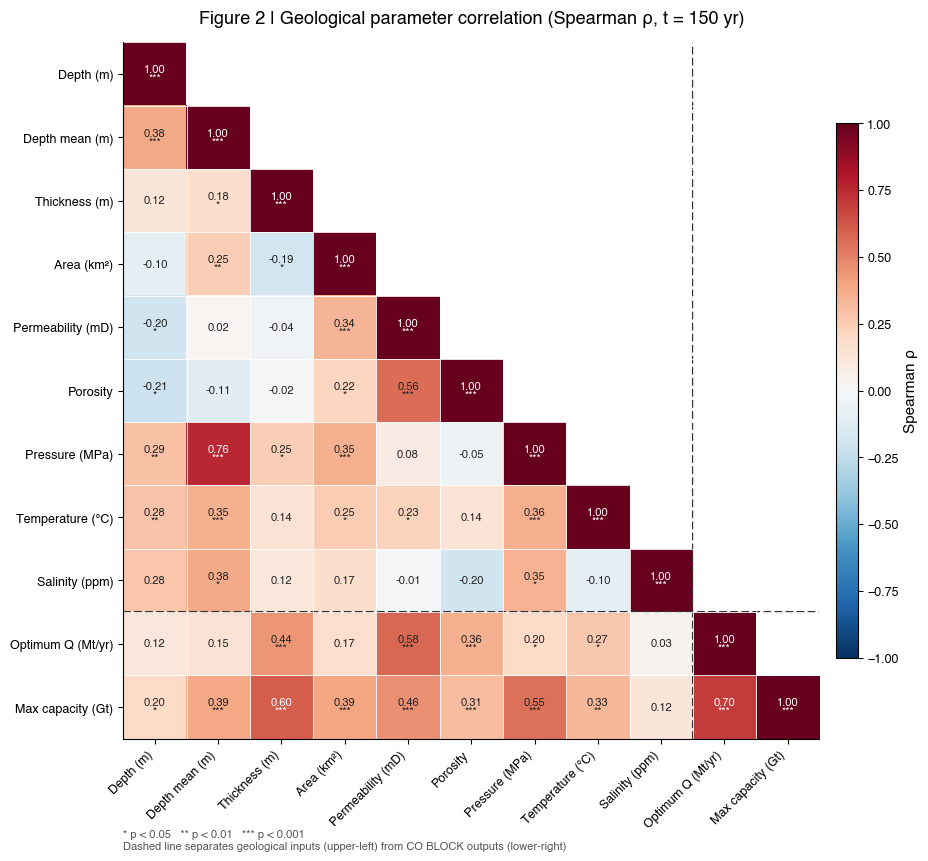

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy import stats as sp_stats

FIGURES_DIR = OUTPUT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Build correlation dataframe: geological inputs + CO₂BLOCK outputs
resource = resource_long.copy()
PERIODS = sorted(resource['Period_yr'].unique())
t_long = max(PERIODS)

t_long_df = resource[resource['Period_yr'] == t_long].copy()

# Merge basin geology with screening outputs
geo_merge = basin_df.merge(
    t_long_df[['Region_no', 'Region_Q_Mt_yr', 'Number_of_Wells',
               'Max_Capacity_Gt', 'Optimum_Q_Mt_yr']],
    left_on='region_no', right_on='Region_no', how='inner',
)

# Select columns with sufficient data (>50% non-NaN)
corr_cols = {}
param_candidates = [
    ('Depth (m)',          'depth - shallowest (m)'),
    ('Depth mean (m)',     'depth - mean (m)'),
    ('Thickness (m)',      'thick (m)'),
    ('Area (km\u00b2)',   'Area (km^2)'),
    ('Permeability (mD)',  'perm (mD)'),
    ('Porosity',           'porosity'),
    ('Pressure (MPa)',     'pressure_mean [Mpa]'),
    ('Temperature (\u00b0C)', 'temperature_mean [C] '),
    ('Salinity (ppm)',     'Salinity [ppm]'),
]
for label, col_name in param_candidates:
    if col_name in geo_merge.columns:
        series = pd.to_numeric(geo_merge[col_name], errors='coerce')
        if series.notna().sum() >= 10:
            corr_cols[label] = series

# Add outputs
corr_cols['Optimum Q (Mt/yr)'] = geo_merge['Optimum_Q_Mt_yr']
corr_cols['Max capacity (Gt)'] = geo_merge['Max_Capacity_Gt']

corr_df = pd.DataFrame(corr_cols)
corr_labels = list(corr_cols.keys())
n_vars = len(corr_labels)
n_input = n_vars - 2  # last 2 are outputs

# Spearman correlation + p-values
corr_matrix = np.full((n_vars, n_vars), np.nan)
pval_matrix = np.full((n_vars, n_vars), np.nan)
for i in range(n_vars):
    for j in range(n_vars):
        valid = corr_df.iloc[:, [i, j]].dropna()
        if len(valid) >= 5:
            rho, pval = sp_stats.spearmanr(valid.iloc[:, 0], valid.iloc[:, 1])
            corr_matrix[i, j] = rho
            pval_matrix[i, j] = pval

# Figure 2: Lower-triangle heatmap
fig2, ax = plt.subplots(figsize=(10, 9))

mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
masked_corr = np.where(mask_upper, np.nan, corr_matrix)

norm_corr = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)
im = ax.imshow(masked_corr, aspect='equal', cmap='RdBu_r', norm=norm_corr,
               interpolation='nearest')

# Annotate cells
for i in range(n_vars):
    for j in range(n_vars):
        if mask_upper[i, j]:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                         facecolor='white', edgecolor='white', lw=0))
            continue
        rho = corr_matrix[i, j]
        pval = pval_matrix[i, j]
        if np.isnan(rho):
            ax.text(j, i, '\u2013', ha='center', va='center',
                    fontsize=8, color='#cccccc')
        else:
            star = ''
            if pval < 0.001:
                star = '***'
            elif pval < 0.01:
                star = '**'
            elif pval < 0.05:
                star = '*'
            txt_color = 'white' if abs(rho) > 0.6 else '#222222'
            weight = 'bold' if abs(rho) > 0.4 else 'normal'
            label = f'{rho:.2f}\n{star}' if star else f'{rho:.2f}'
            ax.text(j, i, label, ha='center', va='center',
                    fontsize=8, fontweight=weight, color=txt_color,
                    linespacing=0.85)

# Separator between inputs and outputs
ax.axhline(n_input - 0.5, color='#333333', lw=1.5, ls='--', clip_on=False)
ax.axvline(n_input - 0.5, color='#333333', lw=1.5, ls='--', clip_on=False)

# Grid
for i in range(n_vars + 1):
    ax.axhline(i - 0.5, color='white', lw=0.6)
    ax.axvline(i - 0.5, color='white', lw=0.6)

ax.set_xticks(range(n_vars))
ax.set_xticklabels(corr_labels, fontsize=9, rotation=45, ha='right')
ax.set_yticks(range(n_vars))
ax.set_yticklabels(corr_labels, fontsize=9)

cb = fig2.colorbar(im, ax=ax, shrink=0.7, pad=0.02, aspect=25)
cb.set_label('Spearman \u03c1', fontsize=11)
cb.ax.tick_params(labelsize=9)

ax.set_title(f'Figure 2 | Geological parameter correlation (Spearman \u03c1, t = {t_long} yr)',
             fontsize=13, fontweight='bold', pad=14)

ax.text(0.0, -0.13,
        '* p < 0.05   ** p < 0.01   *** p < 0.001\n'
        'Dashed line separates geological inputs (upper-left) from CO\u2082BLOCK outputs (lower-right)',
        transform=ax.transAxes, fontsize=8, color='#555555', ha='left', va='top')

fig2.tight_layout()
for fmt in ['pdf', 'png']:
    out = FIGURES_DIR / f'fig2_correlation_heatmap.{fmt}'
    fig2.savefig(out, dpi=300, bbox_inches='tight')
    print(f'Saved: {out}')
plt.show()


## Output files

After running this notebook (or `code/run_step1_precompute.py`), the following
files are saved in `output/step1_precompute/`:

| File | Description |
|------|-------------|
| `precompute/basin_period_resource_long.csv` | Full m × n resource matrix in long format |
| `precompute/basin_metadata.csv` | Basin to country/region mapping |
| `figures/fig1_resource_landscape.pdf` | 5-panel resource landscape figure (a-e) |

These files are the input for Step 2 (`step2_allocation_screening.ipynb` or
`code/run_step2_screening.py`).

### Reusing precomputed results

If the resource matrix has already been generated (by this notebook or by the
standalone script), set `SKIP_PRECOMPUTE = True` at the top of the compute cell
to skip the slow physics step and jump straight to the preview and figure cells.